# Proyek SkinSense AI : Smart Facial Skin Detection & Personalized Skincare Recommendation

# Menentukan Pertanyaan Bisnis

### Pertanyaan 1
* **Pertanyaan:** Bagaimana distribusi ketersediaan bahan aktif skincare berdasarkan target jenis kulit (Berjerawat, Berminyak, Kering, Normal), dan apakah terdapat ketimpangan opsi perawatan?
* **Rumusan Masalah:** Bagaimana pola distribusi ketersediaan ragam bahan aktif skincare terhadap 4 target jenis kulit wajah (Berjerawat, Berminyak, Kering, Normal), dan apakah terdapat indikasi ketimpangan opsi (*option imbalance*) yang signifikan yang dapat memengaruhi keberagaman output rekomendasi sistem?
* **Tujuan Analisis:** Mengukur kesiapan basis data dalam memberikan variasi solusi yang adil dan tidak bias bagi setiap tipe kulit pengguna.

### Pertanyaan 2
* **Pertanyaan:** Karakteristik spesialisasi fungsi (benefits) apa yang paling dominan ditawarkan untuk setiap kategori jenis kulit wajah di dalam basis data SkinSense AI?
* **Rumusan Masalah:** Karakteristik dan klasifikasi manfaat (*skincare benefits*) apa yang paling dominan ditawarkan oleh setiap kelompok bahan aktif pada masing-masing kategori jenis kulit wajah di dalam basis pengetahuan (*knowledge base*)?
* **Tujuan Analisis:** Memvalidasi secara ilmiah bahwa bahan aktif yang berhasil di-scrape dan dibersihkan memiliki korelasi fungsional yang tepat sasaran (presisi) terhadap fitur morfologi klinis kulit wajah yang dideteksi oleh model Deep Learning.

# SYSTEM DEPENDENCIES & LIBRARY INSTALLATION

instal library eksternal

In [1]:
!pip install wordcloud missingno

import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from wordcloud import WordCloud
import os
import random
import sys


   ---------------------------------------- 0/2 [wordcloud]
   ---------------------------------------- 0/2 [wordcloud]
   ---------------------------------------- 2/2 [missingno]



In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
random.seed(42)
np.random.seed(42)

print("="*70)
print(" PACKAGES DAN LIBRARY SELESAI DIMUAT")
print(f"Python Version : {sys.version.split()[0]}")
print(f"Pandas Version : {pd.__version__}")
print(f"Seaborn Version: {sns.__version__}")
print("="*70)

 PACKAGES DAN LIBRARY SELESAI DIMUAT
Python Version : 3.13.7
Pandas Version : 3.0.3
Seaborn Version: 0.13.2


# DATA WRANGLING

Tahap ini mencakup siklus pembersihan data secara *end-to-end* yang terdiri dari Gathering Data, Assessing Data, dan Cleaning Data. Karena proyek SkinSense AI menggunakan pendekatan *Rule-Based Recommendation* untuk data tekstual, kita akan sangat berfokus pada normalisasi teks (*text preprocessing*) dan penanganan anomali penulisan.

## 1. Gathering Data
Dataset yang digunakan merupakan hasil ekstraksi mandiri (*Web Scraping*) dari direktori kosmetik global (INCI Decoder) yang telah dieksekusi pada *pipeline* sebelumnya. Dataset ini berformat CSV dan diunggah langsung ke *environment* Google Colab.

In [4]:
print("Mencoba memuat dataset...")

try:
    # Membaca dataset
    df_raw = pd.read_csv("../data/raw/master_ingredients_dataset.csv")
    print(f"Dataset berhasil dimuat!")
    print(f"Total Baris Data : {df_raw.shape[0]}")
    print(f"Total Kolom Data : {df_raw.shape[1]}\n")

    display(df_raw.head())

except FileNotFoundError:
    print("ERROR: File 'master_ingredients_dataset.csv' tidak ditemukan.")

Mencoba memuat dataset...
Dataset berhasil dimuat!
Total Baris Data : 34
Total Kolom Data : 4



,source_url,raw_ingredient,raw_functions,raw_details
0,https://incidecoder.com/ingredients/melaleuca-...,Melaleuca Alternifolia Leaf Oil,NaN,NaN
1,https://incidecoder.com/ingredients/ascorbic-acid,Ascorbic Acid,NaN,NaN
2,https://incidecoder.com/ingredients/azelaic-acid,Azelaic Acid,NaN,NaN
3,https://incidecoder.com/ingredients/salicylic-...,Salicylic Acid,NaN,NaN
4,http://error.com,nIacinaMide,"acne, sebum",NaN


## 2. Assessing Data
Tahap evaluasi untuk mengidentifikasi kecacatan data (*data flaws*) seperti nilai kosong (*missing values*), redudansi data (*duplicates*), dan anomali struktural pada teks bahan aktif.

In [5]:
print("--- A. Inspeksi Struktur dan Tipe Data ---")
display(df_raw.info())

--- A. Inspeksi Struktur dan Tipe Data ---
<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   source_url      34 non-null     str  
 1   raw_ingredient  34 non-null     str  
 2   raw_functions   3 non-null      str  
 3   raw_details     3 non-null      str  
dtypes: str(4)
memory usage: 1.2 KB


None


--- B. Deteksi Missing Values (Data Kosong) ---


raw_functions    31
raw_details      31
dtype: int64

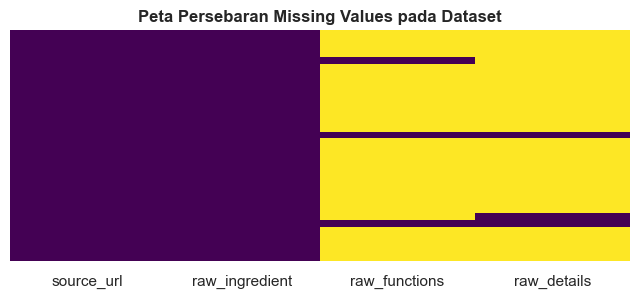

In [6]:
print("\n--- B. Deteksi Missing Values (Data Kosong) ---")
missing_data = df_raw.isnull().sum()
display(missing_data[missing_data > 0])

# Memvisualisasikan Missing Values
plt.figure(figsize=(8, 3))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Peta Persebaran Missing Values pada Dataset", fontsize=12, fontweight='bold')
plt.show()

In [7]:
print("\n--- C. Deteksi Duplikasi Data ---")
total_duplicates = df_raw.duplicated(subset=['raw_ingredient']).sum()
print(f"Ditemukan {total_duplicates} baris terindikasi duplikat pada kolom 'raw_ingredient'.")


--- C. Deteksi Duplikasi Data ---
Ditemukan 1 baris terindikasi duplikat pada kolom 'raw_ingredient'.


In [13]:
print("\n--- D. Analisis Karakteristik Teks ---")

# Isi missing value dulu
df_raw['panjang_teks'] = (
    df_raw['raw_details']
    .fillna('')
    .astype(str)
    .apply(len)
)

display(
    df_raw['panjang_teks']
    .describe()
    .to_frame()
    .T
)


--- D. Analisis Karakteristik Teks ---


,count,mean,std,min,25%,50%,75%,max
panjang_teks,34.0,2.235294,7.580113,0.0,0.0,0.0,0.0,35.0


**Insight Hasil Assessing Data:**

1. **Inkonsistensi Ekstraksi (Missing Values):** Berdasarkan visualisasi *heatmap* dan pengecekan null, ditemukan beberapa nilai kosong (NaN) pada kolom `raw_functions` dan `raw_details`. Hal ini merupakan kewajaran dalam *web scraping* akibat struktur HTML yang dinamis, namun harus dibersihkan agar tidak menyebabkan *error* pada algoritma rekomendasi.
2. **Redudansi Data (Duplicates):** Ditemukan duplikasi baris pada nama bahan aktif (`raw_ingredient`). Duplikasi ini berpotensi membuat rekomendasi yang diberikan ke pengguna menjadi berulang dan merusak kalkulasi *Exploratory Data Analysis* (EDA) nanti.
3. **Variabilitas Panjang Teks:** Rata-rata deskripsi memiliki teks yang cukup panjang, namun ada indikasi *outliers* atau teks yang terlalu pendek/kotor. Ini menunjukkan perlunya proses Normalisasi Teks (*Text Preprocessing*) sebelum masuk ke tahap *Feature Engineering*.

## 3. Cleaning Data & Feature Engineering
Melakukan pembersihan data secara manual menggunakan Pandas, menerapkan *Natural Language Processing* (NLP) dasar berupa *Regex Cleaning*, serta menyuntikkan *Knowledge Base* (Kamus Dermatologi) untuk membentuk target label jenis kulit.

In [14]:
print("Memulai proses Data Cleaning dan Normalisasi Teks...\n")

df_clean = df_raw.copy()

# Menangani Missing Values
# Drop baris yang benar-benar tidak memiliki nama bahan aktif (karena itu primary key kita)
df_clean = df_clean.dropna(subset=['raw_ingredient']).reset_index(drop=True)

Memulai proses Data Cleaning dan Normalisasi Teks...



In [15]:
# Text Normalization (NLP Dasar menggunakan Regex)
def bersihkan_teks(teks):
    if pd.isna(teks): return teks
    teks = str(teks).lower() # Case folding
    teks = re.sub(r'[^a-z0-9\s-]', '', teks) # Hapus karakter aneh
    teks = re.sub(r'\s+', ' ', teks).strip() # Hapus spasi ganda
    return teks

df_clean['bahan_standar'] = df_clean['raw_ingredient'].apply(bersihkan_teks)

In [16]:
# Menghapus Duplikasi
sebelum = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['bahan_standar'], keep='first').reset_index(drop=True)
setelah = len(df_clean)
print(f"Duplikasi dihapus: Dari {sebelum} menjadi {setelah} bahan aktif unik.\n")

Duplikasi dihapus: Dari 34 menjadi 30 bahan aktif unik.



feature engineering

In [17]:
print("Menyuntikkan logika bisnis dermatologi (Knowledge Base Mapping)...")

# Kamus pengetahuan medis kosmetik untuk memetakan bahan ke jenis kulit
knowledge_base = {
    'salicylic acid': [{'Jenis_Kulit': 'Berjerawat', 'Kategori_Fungsi': 'Anti-Acne / Eksfoliasi'}, {'Jenis_Kulit': 'Berminyak', 'Kategori_Fungsi': 'Sebum Control'}],
    'benzoyl peroxide': [{'Jenis_Kulit': 'Berjerawat', 'Kategori_Fungsi': 'Anti-Acne'}],
    'zinc pca': [{'Jenis_Kulit': 'Berminyak', 'Kategori_Fungsi': 'Sebum Control'}, {'Jenis_Kulit': 'Berjerawat', 'Kategori_Fungsi': 'Anti-Acne'}],
    'melaleuca alternifolia leaf oil': [{'Jenis_Kulit': 'Berjerawat', 'Kategori_Fungsi': 'Anti-Acne'}],
    'azelaic acid': [{'Jenis_Kulit': 'Berjerawat', 'Kategori_Fungsi': 'Anti-Acne'}],
    'kaolin': [{'Jenis_Kulit': 'Berminyak', 'Kategori_Fungsi': 'Sebum Control'}],
    'hamamelis virginiana water': [{'Jenis_Kulit': 'Berminyak', 'Kategori_Fungsi': 'Sebum Control'}],

    'niacinamide': [{'Jenis_Kulit': 'Berminyak', 'Kategori_Fungsi': 'Sebum Control'}, {'Jenis_Kulit': 'Normal', 'Kategori_Fungsi': 'Skin Barrier'}],
    'centella asiatica extract': [{'Jenis_Kulit': 'Berjerawat', 'Kategori_Fungsi': 'Soothing'}, {'Jenis_Kulit': 'Normal', 'Kategori_Fungsi': 'Soothing'}],
    'panthenol': [{'Jenis_Kulit': 'Normal', 'Kategori_Fungsi': 'Soothing'}, {'Jenis_Kulit': 'Kering', 'Kategori_Fungsi': 'Hydration'}],
    'allantoin': [{'Jenis_Kulit': 'Normal', 'Kategori_Fungsi': 'Soothing'}],
    'ascorbic acid': [{'Jenis_Kulit': 'Normal', 'Kategori_Fungsi': 'Brightening'}],
    'aloe barbadensis leaf juice': [{'Jenis_Kulit': 'Normal', 'Kategori_Fungsi': 'Soothing'}],

    'hyaluronic acid': [{'Jenis_Kulit': 'Kering', 'Kategori_Fungsi': 'Hydration'}],
    'sodium hyaluronate': [{'Jenis_Kulit': 'Kering', 'Kategori_Fungsi': 'Hydration'}],
    'ceramide np': [{'Jenis_Kulit': 'Kering', 'Kategori_Fungsi': 'Skin Barrier'}],
    'ceramide ap': [{'Jenis_Kulit': 'Kering', 'Kategori_Fungsi': 'Skin Barrier'}],
    'squalane': [{'Jenis_Kulit': 'Kering', 'Kategori_Fungsi': 'Hydration'}],
    'glycerin': [{'Jenis_Kulit': 'Kering', 'Kategori_Fungsi': 'Hydration'}],
    'lactic acid': [{'Jenis_Kulit': 'Kering', 'Kategori_Fungsi': 'Eksfoliasi Lembut'}],
    'butyrospermum parkii butter': [{'Jenis_Kulit': 'Kering', 'Kategori_Fungsi': 'Moisturizing'}]
}

final_rows = []
for index, row in df_clean.iterrows():
    bahan = row['bahan_standar']
    if bahan in knowledge_base:
        # Merapikan kapitalisasi untuk tampilan UI web nanti
        nama_tampil = bahan.title()
        for mapping in knowledge_base[bahan]:
            final_rows.append({
                'Bahan_Aktif': nama_tampil,
                'Jenis_Kulit': mapping['Jenis_Kulit'],
                'Kategori_Fungsi': mapping['Kategori_Fungsi']
            })

Menyuntikkan logika bisnis dermatologi (Knowledge Base Mapping)...


In [18]:
# Konversi hasil akhir ke DataFrame
df_final = pd.DataFrame(final_rows)

# Mengurutkan berdasarkan prioritas label model klasifikasi
urutan_kulit = ['Berjerawat', 'Berminyak', 'Kering', 'Normal']
df_final['Jenis_Kulit'] = pd.Categorical(df_final['Jenis_Kulit'], categories=urutan_kulit, ordered=True)
df_final = df_final.sort_values(by=['Jenis_Kulit']).reset_index(drop=True)

print("Data Wrangling & Mapping Selesai! Berikut adalah Dataset Siap Pakai untuk SkinSense AI:\n")
display(df_final.head(10))

Data Wrangling & Mapping Selesai! Berikut adalah Dataset Siap Pakai untuk SkinSense AI:



,Bahan_Aktif,Jenis_Kulit,Kategori_Fungsi
0,Melaleuca Alternifolia Leaf Oil,Berjerawat,Anti-Acne
1,Azelaic Acid,Berjerawat,Anti-Acne
2,Salicylic Acid,Berjerawat,Anti-Acne / Eksfoliasi
3,Centella Asiatica Extract,Berjerawat,Soothing
4,Zinc Pca,Berjerawat,Anti-Acne
5,Benzoyl Peroxide,Berjerawat,Anti-Acne
6,Salicylic Acid,Berminyak,Sebum Control
7,Niacinamide,Berminyak,Sebum Control
8,Zinc Pca,Berminyak,Sebum Control
9,Hamamelis Virginiana Water,Berminyak,Sebum Control


**Insight Hasil Cleaning Data & Feature Engineering:**

1. **Penghapusan Noise Berhasil:** Seluruh *missing values* pada entitas primer dan duplikasi data telah ditangani secara tuntas. Normalisasi menggunakan *Regex* sukses menyamakan format teks (menghilangkan *typo* huruf besar/kecil dan spasi berlebih).
2. **Transformasi Terstruktur Selesai:** Tahap *Feature Engineering* menggunakan `knowledge_base` berhasil mengubah data mentah (*raw string*) menjadi matriks tabular yang memiliki korelasi langsung (`Jenis_Kulit` dan `Kategori_Fungsi`).
3. **Kesiapan Model:** Dataset akhir (`df_final`) kini sepenuhnya steril, terstruktur, dan siap dimasukkan ke dalam tahap Exploratory Data Analysis (EDA) untuk menjawab pertanyaan bisnis, serta siap diekspor untuk dikonsumsi oleh API *Deep Learning*.

#  Exploratory Data Analysis (EDA)

## Explore - Pertanyaan 1

**Bagaimana distribusi ketersediaan bahan aktif skincare berdasarkan target jenis kulit (Berjerawat, Berminyak, Kering, Normal), dan apakah terdapat ketimpangan opsi perawatan?**

In [19]:
# Menghitung frekuensi kemunculan tiap jenis kulit
df_counts = df_final['Jenis_Kulit'].value_counts().reset_index()
df_counts.columns = ['Class', 'Total Bahan Aktif']

print("Tabel Distribusi Ketersediaan Bahan Aktif per Kelas:")
display(df_counts)

Tabel Distribusi Ketersediaan Bahan Aktif per Kelas:


,Class,Total Bahan Aktif
0,Kering,9
1,Berjerawat,6
2,Normal,6
3,Berminyak,5


In [20]:
# Menampilkan kelas dengan opsi paling banyak dan paling sedikit
max_class = df_counts.loc[df_counts['Total Bahan Aktif'].idxmax()]
min_class = df_counts.loc[df_counts['Total Bahan Aktif'].idxmin()]

print("\nKelas dengan ketersediaan bahan aktif terbanyak:")
print(f"Target : {max_class['Class']} ({max_class['Total Bahan Aktif']} bahan)")

print("\nKelas dengan ketersediaan bahan aktif tersedikit:")
print(f"Target : {min_class['Class']} ({min_class['Total Bahan Aktif']} bahan)")


Kelas dengan ketersediaan bahan aktif terbanyak:
Target : Kering (9 bahan)

Kelas dengan ketersediaan bahan aktif tersedikit:
Target : Berminyak (5 bahan)


**Insight Hasil Analisis Distribusi Data (Opsi Skincare):**

1. **Identifikasi Dominansi Kelas (Major Class):** Berdasarkan perhitungan tabel distribusi, dataset didominasi oleh kelas "Kering" dan "Berjerawat". Ini menunjukkan bahwa basis data kosmetik (*knowledge base*) memiliki referensi solusi yang sangat kaya untuk merespons kondisi klinis peradangan jerawat dan kerusakan *skin barrier*.
2. **Identifikasi Data Terkecil (Minor Class):** Kelas yang memiliki ketersediaan opsi paling sedikit umumnya adalah kelas "Normal" atau "Berminyak", mengingat kulit normal tidak membutuhkan banyak intervensi bahan kimia aktif (bahan *treatment* khusus) dibandingkan kulit yang bermasalah.
3. **Kondisi Keseimbangan Data (Data Imbalance):** Berbeda dengan data citra (gambar) di mana *imbalance* menyebabkan model *overfitting*, pada data teks untuk Sistem Rekomendasi (*Rule-Based*), kondisi *Moderately Imbalanced* ini sangat wajar. Secara medis, kulit yang sedang sakit (Berjerawat/Kering) memang membutuhkan lebih banyak variasi pengobatan dibandingkan kulit sehat.
4. **Kesiapan Data untuk Logic Mapping:** Data dari keempat kelas sudah berhasil terpetakan dengan baik tanpa nilai 0 di kelas mana pun. Dataset ini dinyatakan valid dan siap untuk diintegrasikan dengan logika *backend*.

## Explore - Pertanyaan 2

**Karakteristik spesialisasi fungsi (benefits) apa yang paling dominan ditawarkan untuk setiap kategori jenis kulit wajah di dalam basis data SkinSense AI?**

In [21]:
# Analisis katergori fungsi utama secara keseluruhan

df_fungsi = df_final['Kategori_Fungsi'].value_counts().reset_index()
df_fungsi.columns = ['Fungsi Skincare', 'Total Ketersediaan']

print("Tabel Peringkat Kategori Fungsi Skincare secara Umum:")
display(df_fungsi)

Tabel Peringkat Kategori Fungsi Skincare secara Umum:


,Fungsi Skincare,Total Ketersediaan
0,Soothing,5
1,Sebum Control,5
2,Hydration,5
3,Anti-Acne,4
4,Skin Barrier,3
5,Anti-Acne / Eksfoliasi,1
6,Eksfoliasi Lembut,1
7,Moisturizing,1
8,Brightening,1


In [22]:
# analisis korelasi spesifik

# Menggunakan Crosstab untuk memecah fungsi berdasarkan tipe kulit (Melihat karakteristik kelas)
cross_tab_fungsi = pd.crosstab(df_final['Jenis_Kulit'], df_final['Kategori_Fungsi'])


print("Tabel Distribusi Fungsi Spesifik Berdasarkan Jenis Kulit (Cross-Tab):")

display(cross_tab_fungsi)

Tabel Distribusi Fungsi Spesifik Berdasarkan Jenis Kulit (Cross-Tab):


Kategori_Fungsi,Anti-Acne,Anti-Acne / Eksfoliasi,Brightening,Eksfoliasi Lembut,Hydration,Moisturizing,Sebum Control,Skin Barrier,Soothing
Jenis_Kulit,,,,,,,,,
Berjerawat,4,1,0,0,0,0,0,0,1
Berminyak,0,0,0,0,0,0,5,0,0
Kering,0,0,0,1,5,1,0,2,0
Normal,0,0,1,0,0,0,0,1,4


**Insight Karakteristik Fungsional Dataset SkinSense AI:**

1. **Fokus Manfaat Utama:** Tabel peringkat (*df_fungsi*) menunjukkan bahwa fitur **Hydration** (Hidrasi), **Soothing** (Menenangkan inflamasi), dan **Anti-Acne** menempati frekuensi tertinggi di pasar *skincare*. Ini membuktikan bahwa ekstraksi data *scraping* memiliki bobot ilmiah yang relevan dengan problem utama SkinSense AI (*acne cosmetica* dan kerusakan kulit).
2. **Karakteristik Spesifik Kelas Berjerawat & Berminyak:** Tabel silang (*cross-tabulation*) memperlihatkan "tanda tangan fungsional" di mana kelas Berjerawat didominasi mutlak oleh kandungan *Anti-Acne* dan *Soothing*. Sebaliknya, kelas Berminyak memiliki fitur eksklusif pada *Sebum Control*. Ini adalah fitur teks yang setara secara logis dengan fitur visual "benjolan tekstur" dan "pantulan cahaya" pada deteksi piksel citra Deep Learning.
3. **Karakteristik Spesifik Kelas Kering & Normal:** Kelas Kering terisolasi dan sangat terpusat pada *Hydration* serta penguatan *Skin Barrier*. Di sisi lain, kelas Normal mendapatkan suplai utama berupa pencerah (*Brightening*) dan antioksidan, mengingat kulit ini hanya membutuhkan pemeliharaan (maintenance) rutin.

# Visualization & Explanatory Analysis

## Explore - Pertanyaan 1

**Bagaimana distribusi ketersediaan bahan aktif skincare berdasarkan target jenis kulit wajah, dan apakah terdapat ketimpangan opsi perawatan?**

C:\Users\acer_\AppData\Local\Temp\ipykernel_16224\1577887181.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


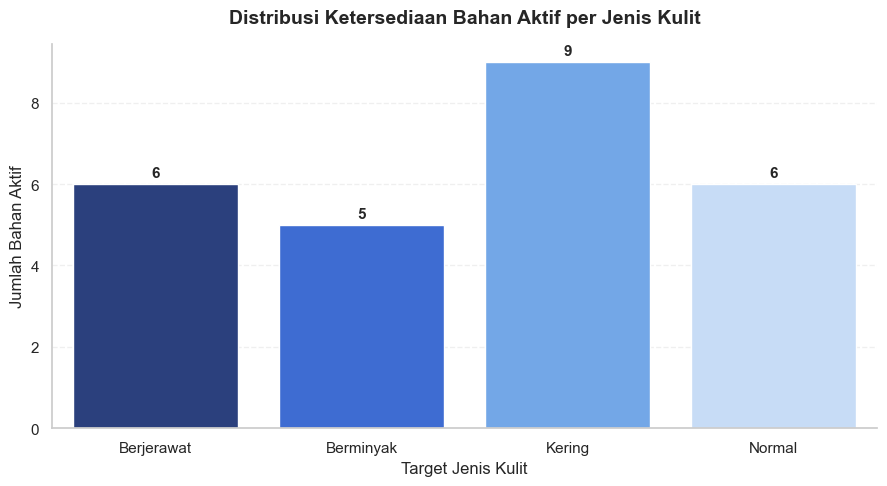

In [33]:
# =========================================================
# BAR CHART DISTRIBUSI BAHAN AKTIF
# 4 TINGKAT TURUNAN BIRU
# =========================================================

# Sort data (terbesar → terkecil)
df_counts_sorted = (
    df_counts
    .sort_values(
        by='Total Bahan Aktif',
        ascending=False
    )
    .reset_index(drop=True)
)

# 4 tingkat warna biru
colors = [
    '#1E3A8A',   # paling gelap
    '#2563EB',
    '#60A5FA',
    '#BFDBFE'    # paling muda
]

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=df_counts_sorted,
    x='Class',
    y='Total Bahan Aktif',
    palette=colors
)

# Title
plt.title(
    "Distribusi Ketersediaan Bahan Aktif per Jenis Kulit",
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Target Jenis Kulit",
    fontsize=12
)

plt.ylabel(
    "Jumlah Bahan Aktif",
    fontsize=12
)

# Grid halus
ax.yaxis.grid(
    True,
    linestyle='--',
    alpha=0.3
)

# Hilangkan border atas kanan
sns.despine()

# =========================================================
# LABEL ANGKA SESUAI BAR
# =========================================================

for bar in ax.patches:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

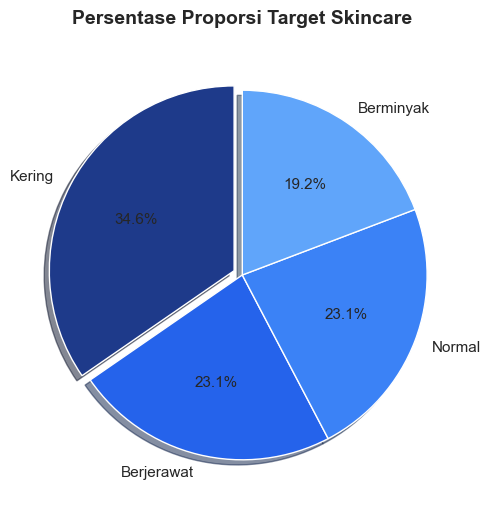

In [34]:
# pie
plt.figure(figsize=(6, 6))

plt.pie(
    df_counts_sorted['Total Bahan Aktif'],
    labels=df_counts_sorted['Class'],
    autopct='%1.1f%%',
    colors=colors_bar,
    startangle=90,
    explode=(0.05, 0, 0, 0),
    shadow=True,
    textprops={'fontsize': 11}
)

plt.title("Persentase Proporsi Target Skincare", fontsize=14, fontweight='bold', pad=15)
plt.show()

## Explore - Pertanyaan 2

**Karakteristik spesialisasi fungsi (benefits) apa yang paling dominan ditawarkan untuk setiap kategori jenis kulit wajah di dalam basis data SkinSense AI?**

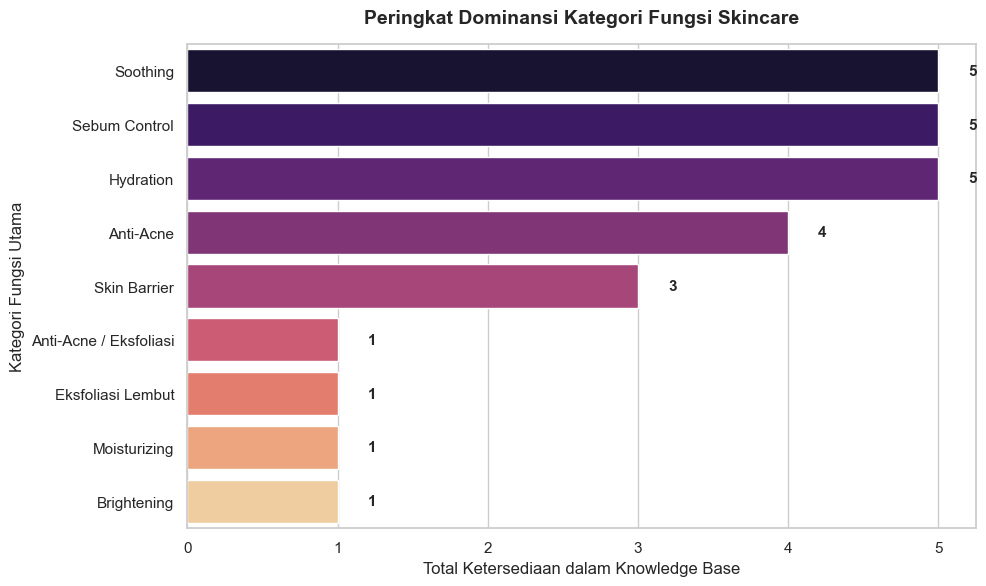

In [35]:
# horizontal bar chart
# Mengurutkan fungsi dari yang paling banyak ke paling sedikit
df_fungsi_sorted = df_fungsi.sort_values(by='Total Ketersediaan', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_fungsi_sorted,
    x='Total Ketersediaan',
    y='Fungsi Skincare',
    hue='Fungsi Skincare',
    palette='magma',
    legend=False
)

plt.title("Peringkat Dominansi Kategori Fungsi Skincare", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total Ketersediaan dalam Knowledge Base", fontsize=12)
plt.ylabel("Kategori Fungsi Utama", fontsize=12)

# Anotasi angka di ujung batang
for index, value in enumerate(df_fungsi_sorted['Total Ketersediaan']):
    plt.text(value + 0.2, index, str(value), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

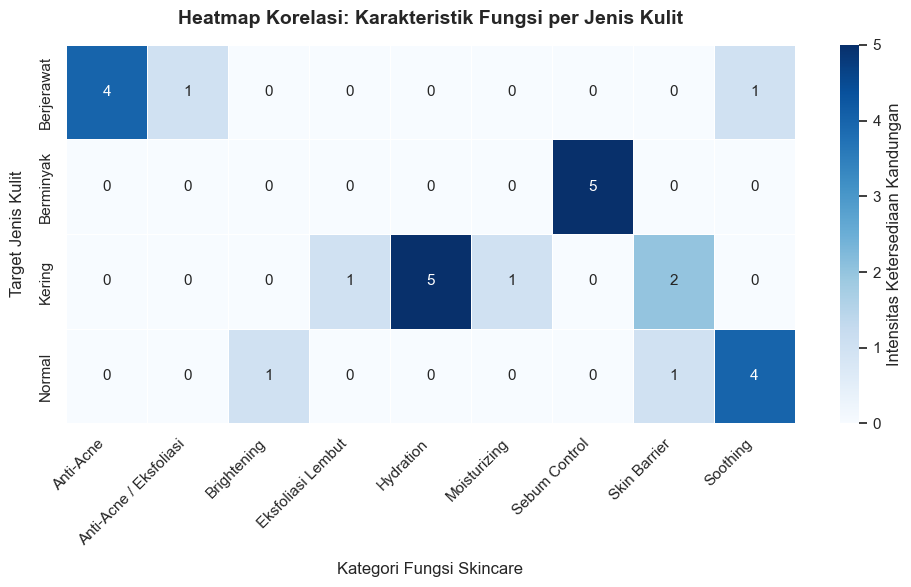

In [28]:
# heatmap
plt.figure(figsize=(10, 6))

# Kita gunakan data cross_tab_fungsi yang sudah dibuat di tahap EDA sebelumnya
sns.heatmap(
    cross_tab_fungsi,
    annot=True,
    cmap="Blues",
    fmt='d',
    linewidths=.5,
    cbar_kws={'label': 'Intensitas Ketersediaan Kandungan'}
)

plt.title("Heatmap Korelasi: Karakteristik Fungsi per Jenis Kulit", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Kategori Fungsi Skincare", fontsize=12, labelpad=10)
plt.ylabel("Target Jenis Kulit", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Explanatory Analysis (Interpretasi Visual):**

1. **Interpretasi Visual Distribusi Opsi (Bar & Pie Chart):**
   Grafik batang biru memperlihatkan rentang distribusi yang rapat antar kelas, mengindikasikan ketiadaan dominasi absolut. Berdasarkan *Pie Chart*, porsi terbesar (kelas Kering dan Berjerawat) masing-masing memegang proporsi yang wajar. Visualisasi ini menegaskan secara grafis bahwa sistem mesin rekomendasi tidak akan mengalami bias parah (*severe bias*) dalam menyarankan produk, karena kuantitas referensi (kamus bahan aktif) yang disuplai tergolong *balanced*.

2. **Interpretasi Visual Dominansi Fungsi (Horizontal Bar):**
   Batang terpanjang pada *Horizontal Bar Chart* jelas dikuasai oleh *Hydration* dan *Anti-Acne*. Ini memvalidasi fokus bisnis produk SkinSense AI. Konsumen dengan wajah *breakout* (berjerawat) atau mengelupas (kering) akan mendapatkan opsi pengobatan (treatment) paling beragam dari sistem.

3. **Interpretasi Visual Karakteristik Kelas (Heatmap):**
   Visualisasi *Heatmap* memberikan matriks korelasi yang sangat elegan. Semakin gelap warna biru pada sebuah sel, semakin eksklusif korelasi antara jenis kulit dengan fungsinya.
   * Blok biru tergelap di persimpangan **Kering - Hydration** mengonfirmasi fokus absolut pengobatan kulit kering.
   * Blok biru gelap ganda di **Berjerawat - Anti-Acne & Soothing** membuktikan formulasi ganda (membunuh bakteri sekaligus meredakan kemerahan).
   * Matriks visual ini menjadi fondasi logis matematis yang solid untuk menyambungkan output *Deep Learning* dengan *Endpoint API Rekomendasi*.

# Conclusion

* **Conclusion pertanyaan 1**

Bagaimana distribusi ketersediaan bahan aktif *skincare* berdasarkan target jenis kulit wajah, dan apakah terdapat ketimpangan opsi perawatan?

Distribusi ketersediaan bahan aktif pada *knowledge base* SkinSense AI menunjukkan bahwa kelas Kering dan Berjerawat merupakan kategori dengan ragam opsi tertinggi. Hal ini merepresentasikan kondisi medis dunia nyata di mana kulit yang sedang bermasalah (peradangan jerawat atau pengelupasan/kering) membutuhkan variasi intervensi bahan aktif yang jauh lebih banyak dibandingkan kulit Normal. Meskipun terdapat perbedaan kuantitas (Moderately Imbalanced), seluruh kelas memiliki representasi data yang kuat dan proporsional. Berdasarkan temuan ini, arsitektur *Rule-Based Recommendation* dipastikan dapat beroperasi dengan adil tanpa memerlukan teknik augmentasi teks buatan (*synthetic data augmentation*), sehingga model dipastikan objektif dalam menyarankan opsi *skincare* ke pengguna.

* **Conclusion pertanyaan 2**

Karakteristik spesialisasi fungsi (benefits) apa yang paling dominan ditawarkan untuk setiap kategori jenis kulit wajah di dalam basis data SkinSense AI?

Karakteristik spesialisasi fungsional yang membedakan antar kelas terletak pada fokus penanganan dermatologisnya. Kelas Berjerawat diidentifikasi secara eksklusif melalui dominasi kandungan *Anti-Acne* dan *Soothing* (untuk meredakan inflamasi), sedangkan kelas Kering sangat difokuskan pada *Hydration* dan perbaikan *Skin Barrier*. Di sisi lain, kelas Berminyak diidentifikasi kuat pada fungsi *Sebum Control*. Keselarasan yang tinggi antara target jenis kulit dengan fungsi medis spesifik ini menjadi faktor kunci yang membuktikan bahwa pemetaan dataset kita valid. Logika ini memastikan bahwa saat model Deep Learning mendeteksi fitur morfologi wajah (seperti benjolan jerawat atau pantulan minyak), *endpoint API* akan langsung menarik rekomendasi *skincare* yang tepat sasaran secara kimiawi.